# Código implementación del problema Minimal Maximal Matching (MMM) en computadores cuánticos de átomos neutros

En este código se emula la resolución del MMM a través de la biblioteca Bloqade, desarrollada por QuEra. Su implementación está basada en los siguientes tutoriales:

https://github.com/QuEraComputing/quera-education/tree/main/Bloqade_Python_Tutorial

https://docs.pasqal.com/pulser/tutorials/qubo/

Para obtener una primera impresión de los resultados se recomienda ejecutar el código de principio a fin. Posteriormente en las diferentes celdas donde se obtienen los diferentes resultados se pueden ir variando los parámetros simulados y los grafos considerados para ver cómo cambian (ambos definidos al principio de cada celda).

In [ ]:
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import piecewise_linear, cast
from bloqade.analog.atom_arrangement import ListOfLocations, Lieb, Square, Chain, Honeycomb, Kagome, Triangular, Rectangular
import numpy as np
from IPython.display import display, HTML
from scipy.optimize import curve_fit
from bokeh.io import output_notebook
import csv
from pathlib import Path
import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
import time

# Funciones básicas

In [2]:
def resolucion_clasica(Q_exacta, print_resultados = False):
    """
    Resuelve un problema QUBO por fuerza bruta (enumeración exhaustiva).

    Parámetros
    ----------
    Q       : array-like – Matriz QUBO.
    verbose : bool       – Si True, imprime las mejores soluciones.

    Retorna
    -------
    sort_zipped : list[(str, float)] – Todos los bitstrings ordenados por coste.
    """
    Q_exacta = np.array(Q_exacta)

    bitstrings = [np.binary_repr(i, len(Q_exacta)) for i in range(2 ** len(Q_exacta))]
    costs = []
    
    for b in bitstrings:
        z = np.array(list(b), dtype=int)
        cost = z @ Q_exacta @ z
        costs.append(cost)
    zipped = zip(bitstrings, costs)
    sort_zipped = sorted(zipped, key=lambda x: x[1])

    if print_resultados:
        print(f"---Solución clásica: \n {sort_zipped[:6]} \n")

    return sort_zipped
# Ejecución de la función 
#sort_zipped = resolucion_clasica(Q_exacta)


# Determinamos la geometría de los átomos para Q
def construir_geometria(Q, seed=0, tol=1e-6, maxiter=200000, plot=False, x0_func=None):
    """
    Optimiza las coordenadas atómicas para que las interacciones Rydberg
    reproduzcan la matriz QUBO, y construye la geometría de Bloqade.

    Parámetros
    ----------
    Q       : array-like – Matriz QUBO (simétrica).
    seed    : int        – Semilla para reproducibilidad.
    tol     : float      – Tolerancia del optimizador Nelder-Mead.
    maxiter : int        – Máximo de iteraciones.
    plot    : bool       – Si True, dibuja el registro Pulser y la geometría Bloqade.

    Retorna
    -------
    geometria : bloqade Program – Geometría lista para montar el programa.
    coords    : np.ndarray      – Coordenadas optimizadas (n×2).
    """
    Q = np.array(Q)
    device = pulser.DigitalAnalogDevice

    def evaluate_mapping(new_coords):
        new_coords = np.reshape(new_coords, (len(Q), 2))
        new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
        return np.linalg.norm(new_Q - Q)

    # Por si queremos cambiar el x0:
    if x0_func is not None:
        x0 = x0_func(A, Q)
    else:
        np.random.seed(seed)
        x0 = np.random.random(len(Q) * 2)

    #if random_x0 == True:
    #    np.random.seed(seed)
    #    x0 = np.random.random(len(Q) * 2)
    #elif random_x0 == False:
    #    C6 = 2 * np.pi * 862690
    #    d_init = (C6 / A) ** (1/6)
    #    x0 = np.array([[i * d_init, 0.0] for i in range(len(Q))]).flatten() #Esto es para colocar los átomos en línea, con la distancia inicial d_init

    res = minimize(
        evaluate_mapping,
        x0,
        method="Nelder-Mead",
        tol=tol,
        options={"maxiter": maxiter, "maxfev": None},
    )

    coords = np.reshape(res.x, (len(Q), 2))

    if plot:
        # Visualización Pulser
        #coord_dict = {f"q{i}": coord for i, coord in enumerate(coords)}
        #reg = pulser.Register(coord_dict)
        #reg.draw(
        #    blockade_radius=device.rydberg_blockade_radius(1),
        #    draw_graph=False,
        #    draw_half_radius=True,
        #)
        coord_dict = {f"e{i}": coord for i, coord in enumerate(coords)}
        reg = pulser.Register(coord_dict)
        # Radio de bloqueo operativo: el omega_max que se usa en resolver_qubo
        omega_max = 0.9 * np.min(-np.diag(Q))
        reg.draw(
            blockade_radius=device.rydberg_blockade_radius(omega_max),
            draw_graph=False,
            draw_half_radius=True,
        )
        print(f"Coordenadas optimizadas:\n{coords}")

    # Construcción Bloqade
    coordenadas = [tuple(pt) for pt in coords.tolist()]
    geometria = start.add_position(coordenadas)

    if plot:
        geometria.show()

    return geometria, coords
# Ejecución de la función 
#geometria, coords = construir_geometria(Q)


def resolver_qubo(Q, geometria, sort_zipped, A, B, C=0,
                    sweep_time=11.0, plot=False, n_shots=10000):
    """
    Ejecuta la simulación de átomos neutros para un problema QUBO dado.

    Parámetros
    ----------
    Q             : array-like  – Matriz QUBO.
    geometria     : Register     – Geometría de átomos (Bloqade).
    sort_zipped   : list[(str, float)] – Soluciones clásicas ordenadas (bitstring, energía).
    A, B, C       : float        – Coeficientes QUBO (solo para etiquetas).
    omega_max     : float        – Amplitud máxima de la frecuencia de Rabi.
    sweep_time    : float        – Tiempo de evolución adiabática [µs].
    plot          : bool         – Si True, muestra el histograma.
    n_shots       : int          – Número de disparos de la simulación.
    sweep_time    : float        – Tiempo de evolución adiabática [µs].
    plot          : bool         – Si True, muestra el histograma.

    Retorna
    -------
    prob_exito    : float        – Probabilidad de medir la solución correcta.
    counts_str    : dict         – {bitstring: conteos}.
    """
    # ── PASO 1: Detunings locales desde la diagonal de Q ──
    Q = np.array(Q)
    delta_local = -np.diag(Q)
    delta_end   = np.max(delta_local)
    escalas     = (delta_local / delta_end).tolist()

    # ── PASO 2: Parámetros de pulso ──
    omega_max = 0.9 * np.min(np.abs(delta_local))
    sweep_time= sweep_time
    durations             = [0.8, sweep_time, 0.8]
    rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
    rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

    # ── PASO 3: Simulación ──
    prog = (
        geometria
        .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
        .detuning.scale(escalas).piecewise_linear(durations, rabi_detuning_values)
    )
    emu_prog = prog.bloqade.python().run(shots=n_shots)
    report   = emu_prog.report()
    if plot:
        report.show()


    # ── PASO 4: Análisis ──
    counts = report.counts()[0]
    counts_str = {
        "".join(str(b) for b in estado): n
        for estado, n in counts.items()
    }

    energia_minima   = sort_zipped[0][1]
    soluciones_validas = [b for b, e in sort_zipped if e == energia_minima]

    exitos     = sum(counts_str.get(s, 0) for s in soluciones_validas)
    prob_exito = exitos / n_shots

    # ── PASO 5: Resultados ──
    if plot:
        print(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
        print(f"  Soluciones válidas: {soluciones_validas}  (E = {energia_minima:.3f})")
        print(f"  Conteos solución:   {exitos} / {n_shots}")
        counts_ordenado = dict(sorted(counts_str.items(), key=lambda x: x[1], reverse=True))
        colores = ["r" if b in soluciones_validas else "steelblue" for b in counts_ordenado]
        plt.figure(figsize=(12, 5))
        plt.bar(counts_ordenado.keys(), counts_ordenado.values(), color=colores, width=0.5)
        plt.xlabel("Bitstrings")
        plt.ylabel("Conteos")
        plt.title(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
        plt.xticks(rotation=90, fontsize=7)
        plt.tight_layout()
        plt.show()

    return prob_exito, counts_str

# Ejecución de la función 
# prob, counts = resolver_qubo(Q, geometria, sort_zipped, A, B, C)

# Grafos

In [3]:
Q_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
Q_exacta_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
def x0_func_P3(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


Q_func_P4 = lambda A, B, C: np.array(
    [[-2*B+C, A+2*B, 0      ],
     [0,      -3*B+C, A+2*B ],
     [0,       0,     -2*B+C]]
)
Q_exacta_func_P4 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B,       B],
    [0,      -3*B+C,  A+2*B],
    [0,       0,     -2*B+C]
])
def x0_func_P4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


Q_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_exacta_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0     ],
    [0,      -3*B+C, A+2*B, B     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
def x0_func_P5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


Q_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  0     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_exacta_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0    ],
    [0,      -3*B+C, A+2*B, B,      0     ],
    [0,       0,    -3*B+C, A+2*B,  B     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
def x0_func_P6(A, Q):
    C6 = 2 * np.pi * 862690
    # Mayor entrada off-diagonal = A+2B (acoplamiento adyacente en L(G))
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    return np.array([
        [0*d, 0.0], [1*d, 0.0], [2*d, 0.0], [3*d, 0.0], [4*d, 0.0],
    ]).flatten()


Q_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   0,    0],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_exacta_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   B,    B],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
def x0_func_Y_horizontal(A, Q):
    C6 = 2 * np.pi * 862690  # rad·µs⁻¹·µm⁶
    d = (C6 / A) ** (1/6)    # distancia inicial de referencia
    return np.array([
        [-d,        0.0],   # e0 (extremo izquierdo)
        [ 0.0,      0.0],   # e1 (centro)
        [ d * 0.7,  d * 0.7],   # e2 (rama superior derecha)
        [ d * 0.7, -d * 0.7],   # e3 (rama inferior derecha)
    ]).flatten()


Q_exacta_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 2*B,   A+2*B],
    [0,      -3*B+C, A+2*B, 2*B  ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,     A+2*B],
    [0,      -3*B+C, A+2*B, 0   ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
def x0_func_C4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 4 átomos en cuadrado de lado d
    return np.array([
        [0.0, 0.0],
        [d,   0.0],
        [d,   d  ],
        [0.0, d  ],
    ]).flatten()


Q_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 0,      A+2*B, A+2*B], 
    [0,      -3*B+C, A+2*B, 0,     0    ],  
    [0,       0,    -3*B+C, A+2*B, 0    ],  
    [0,       0,     0,    -4*B+C, A+2*B],  
    [0,       0,     0,     0,    -3*B+C],  
])
Q_exacta_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 2*B,   A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B, 2*B,  B    ],
    [0,       0,    -3*B+C, A+2*B, B    ],
    [0,       0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,    -3*B+C],
])
def x0_func_C4mod(A, Q):
    C6 = 2 * np.pi * 862690
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    return np.array([
        [ 0.0,             0.0 ],
        [ d,               0.0 ],
        [ d,               d   ],
        [ 0.0,             d   ],
        [-d*np.sqrt(3)/2,  d/2 ],
    ]).flatten()


Q_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0    ],
    [0,      0,      -3*B+C, A+2*B, 0    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      B    ],
    [0,      0,      -3*B+C, A+2*B, B    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
def x0_func_C5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 5 átomos en pentágono regular de lado d
    # radio del circuncírculo: R = d / (2 sin(pi/5))
    R = d / (2 * np.sin(np.pi / 5))
    return np.array([
        [R * np.cos(2*np.pi*k/5 + np.pi/2), R * np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ]).flatten()


Q_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,     A+2*B, 0    ],
    [0,      -3*B+C, A+2*B, 0,     0,     0    ],
    [0,       0,    -3*B+C, A+2*B, 0,     0    ],
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],
    [0,       0,     0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,     0,    -3*B+C],
])
Q_exacta_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,     A+2*B, B    ],
    [0,      -3*B+C, A+2*B, B,     B,     0    ],
    [0,       0,    -3*B+C, A+2*B, B,     B    ],
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],
    [0,       0,     0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,     0,    -3*B+C],
])
def x0_func_C5mod(A, Q):
    C6 = 2 * np.pi * 862690
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    R = d / (2 * np.sin(np.pi / 5))
    pent = np.array([
        [R*np.cos(2*np.pi*k/5 + np.pi/2), R*np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ])
    # x_5 = (4,5) en triángulo equilátero con x_3=(3,4) y x_4=(4,0)
    p3, p4 = pent[3], pent[4]
    mid = (p3 + p4) / 2
    perp = np.array([-(p4-p3)[1], (p4-p3)[0]])
    perp = perp / np.linalg.norm(perp)
    if np.dot(perp, mid) < 0:
        perp = -perp
    p5 = mid + perp * (d * np.sqrt(3) / 2)
    return np.vstack([pent, p5]).flatten()


Q_exacta_func_K13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_func_K13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
def x0_func_K13(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # L(K_{1,3}) = K_3: triángulo equilátero de lado d
    return np.array([
        [0.0,      0.0   ],
        [d,        0.0   ],
        [d/2, d*np.sqrt(3)/2],
    ]).flatten()



# A contiuación se encuentran los grafos que dan problema
Q_func_P7 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  0,      0     ],
    [0,       0,     0,    -3*B+C,  A+2*B,  0     ],
    [0,       0,     0,     0,     -3*B+C,  A+2*B ],
    [0,       0,     0,     0,      0,     -2*B+C ]
])
Q_exacta_func_P7 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, B,      0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  B,      0     ],
    [0,       0,     0,    -3*B+C,  A+2*B,  B     ],
    [0,       0,     0,     0,     -3*B+C,  A+2*B ],
    [0,       0,     0,     0,      0,     -2*B+C ]
])
def x0_func_P7(A, Q):
    C6 = 2 * np.pi * 862690
    # Mayor entrada off-diagonal = A+2B (acoplamiento adyacente en L(G))
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    return np.array([
        [0*d, 0.0], [1*d, 0.0], [2*d, 0.0], [3*d, 0.0], [4*d, 0.0], [5*d, 0.0],
    ]).flatten()


Q_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0,      0    ],
    [0,       0,    -3*B+C, A+2*B,  0,      0    ],
    [0,       0,     0,    -3*B+C,  A+2*B,  0    ],
    [0,       0,     0,     0,     -3*B+C,  A+2*B],
    [0,       0,     0,     0,      0,     -3*B+C]
])
Q_exacta_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      0,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      0,      B    ],
    [0,       0,    -3*B+C, A+2*B,  B,      0    ],
    [0,       0,     0,    -3*B+C,  A+2*B,  B    ],
    [0,       0,     0,     0,     -3*B+C,  A+2*B],
    [0,       0,     0,     0,      0,     -3*B+C]
])
def x0_func_C6(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 6 átomos en hexágono regular de lado d
    # radio del circuncírculo: R = d / (2 sin(pi/6)) = d
    R = d / (2 * np.sin(np.pi / 6))
    return np.array([
        [R * np.cos(2*np.pi*k/6 + np.pi/2), R * np.sin(2*np.pi*k/6 + np.pi/2)]
        for k in range(6)
    ]).flatten()

# Resolución 1 caso
La siguiente celda permite comprobar la metodología para una ejecución concreta y comparar los diferentes estados alcanzados.

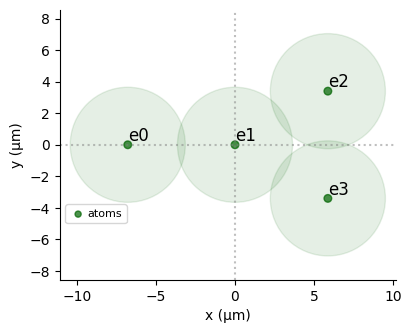

Coordenadas optimizadas:
[[-6.79684431e+00  3.69517965e-04]
 [-8.84625024e-05  4.62186687e-04]
 [ 5.88596282e+00  3.39867951e+00]
 [ 5.88605680e+00 -3.39759234e+00]]


-6796844.31473667 5886056.796083842 -3397592.336084676 3398679.5058111446


A=50, B=30.0, C=20.0  →  P(éxito) = 82.79%
  Soluciones válidas: ['0100']  (E = -100.000)
  Conteos solución:   8279 / 10000


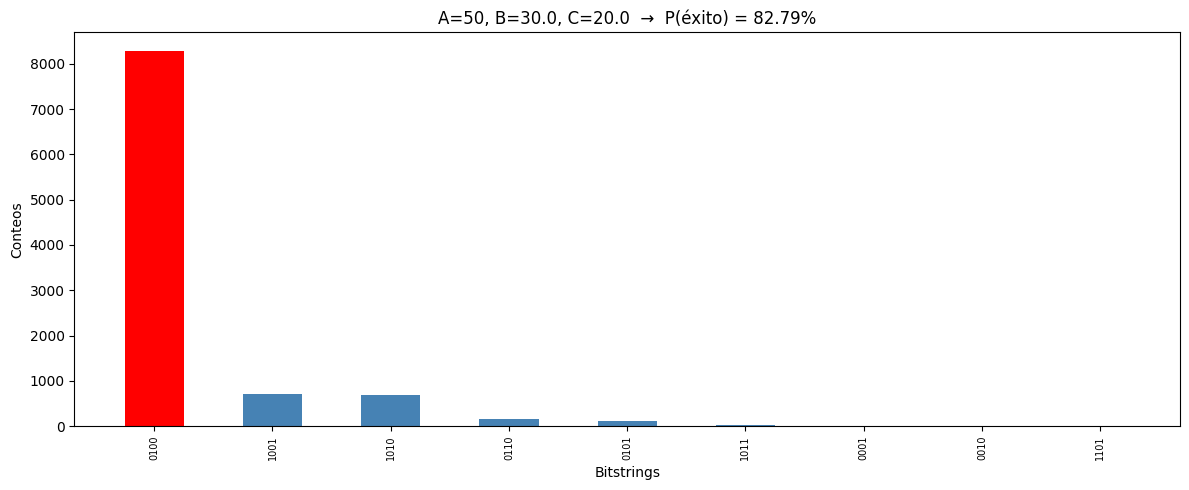

In [4]:
for k in [1]:
    A = A_solucion = 50
    B = B_solucion = 0.6*A_solucion
    C = C_solucion = 0.4*A_solucion
    Q_exacta_func = Q_exacta_func_Y
    Q_func = Q_func_Y
    x0_func = x0_func_Y_horizontal
    

    sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion))
    Q = Q_func(A, B, C)
    geometria, _       = construir_geometria(Q, plot=True, x0_func=x0_func)
    prob, _            = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=True)

    A_values = [A]
    B_values = [B]
    C_values = [C]

# $T_\text{barrido}$

La siguiente celda simula para diferentes grafos la evolución de $P_{éxito}$ al variar el tiempo de barrido. Para cambiar los grafos simulados basta con dejar sin comentar su línea en _grafos_.


  AJUSTE: P(T) = P_inf · (1 - exp(-β·T))
  Grafo           P_inf         β (1/µs)         R²        RSS  dof
  ──────────────────────────────────────────────────────────────
  P3         0.7926±0.0182  18.05±1.56      0.8611     0.1409  36
  P4         0.9725±0.0056  19.13±0.43      0.9898     0.0145  36
  P5         0.8393±0.0051  22.39±0.59      0.9833     0.0149  36
  P6         0.9502±0.0319  15.93±1.85      0.8607     0.3453  36

Parámetros: A=50, B/A=0.7, C/A=0.35, T=[0.015, 0.274] µs, step=0.007 µs, 


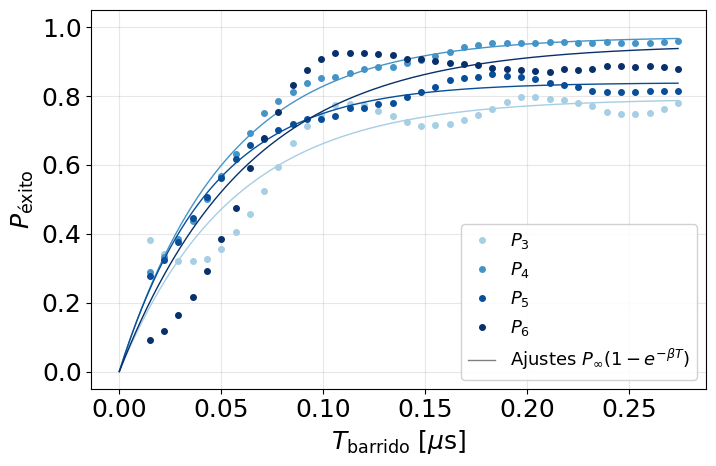

In [5]:
A = 50
ratio_B = 0.7
ratio_C = 0.35
B = ratio_B * A
C = ratio_C * A

grafos = {
    "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
    "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),

    # "K13": (Q_func_K13, Q_exacta_func_K13, x0_func_K13),
    # "C4": (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    # "C5": (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    # "C4mod": (Q_func_C4mod, Q_exacta_func_C4mod, x0_func_C4mod),
    # "Y": (Q_func_Y, Q_exacta_func_Y, x0_func_Y_horizontal),
}

T_values = np.arange(0.015, 0.28, 0.007)


resultados_T = {} 
tiempos_T = {}  

for nombre, (Q_func_g, Q_exacta_func_g, x0_func_g) in grafos.items():
    inicio_grafo = time.time()

    Q = Q_func_g(A, B, C)
    Q_exacta = Q_exacta_func_g(A, B, C)

    diag = -np.diag(Q)
    if np.any(diag <= 0):
        print(f"  {nombre}: detuning <=0 con A={A}, B={B}, C={C}. Se omite.")
        continue

    sort_zipped = resolucion_clasica(Q_exacta)

    for T in T_values:
        probs = []
        tiempos = []
        n_repeticiones = 6
        for rep in range(n_repeticiones):
            try:
                t0 = time.time()
                geometria, _ = construir_geometria(Q, seed=rep, plot=False, x0_func=x0_func_g)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, sweep_time=T, plot=False, n_shots=2000)
                t1 = time.time()
                probs.append(prob)
                tiempos.append(t1 - t0)
            except RuntimeError as e:
                print(f"  T={T}, rep={rep}: {e}")
                probs.append(np.nan)
                tiempos.append(np.nan)

        resultados_T[(nombre, T)] = probs
        tiempos_T[(nombre, T)] = tiempos

    fin_grafo = time.time()
    # print(f"\n=== El grafo {nombre} ha tardado en ejecutarse {fin_grafo - inicio_grafo:.2f} segundos ===")

medias_T = {}
for nombre in grafos.keys():
    medias_T[nombre] = np.array([np.nanmean(resultados_T[(nombre, T)]) for T in T_values])



#  AJUSTE LANDAU-ZENER:  P(T) = P_inf * (1 - exp(-beta * T))

def modelo_LZ_T(T, P_inf, beta):
    """P(T) = P_inf * (1 - exp(-beta * T))"""
    return P_inf * (1.0 - np.exp(-beta * T))

def ajustar_LZ_T(T_vals, P_vals):
    """Ajusta modelo_LZ_T y devuelve (popt, perr, R2, RSS, dof)."""
    mask = ~np.isnan(P_vals)
    T_clean = np.array(T_vals)[mask]
    P_clean = np.array(P_vals)[mask]
    
    popt, pcov = curve_fit(modelo_LZ_T, T_clean, P_clean, p0=(0.9, 50.0), maxfev=10000,
                           bounds=([0, 0], [1.05, np.inf]))
    perr = np.sqrt(np.diag(pcov))
    P_pred = modelo_LZ_T(T_clean, *popt)
    residuos = P_clean - P_pred
    RSS = np.sum(residuos**2)
    SS_tot = np.sum((P_clean - np.mean(P_clean))**2)
    R2 = 1.0 - RSS / SS_tot if SS_tot != 0 else 0
    dof = len(T_clean) - len(popt)
    return popt, perr, R2, RSS, dof

print("\n" + "="*70)
print("  AJUSTE: P(T) = P_inf · (1 - exp(-β·T))")
print("="*70)
print(f"  {'Grafo':<10} {'P_inf':>10} {'β (1/µs)':>16} {'R²':>10} {'RSS':>10}  dof")
print(f"  {'─'*62}")

ajustes_T = {}
for nombre in grafos.keys():
    popt, perr, R2, RSS, dof = ajustar_LZ_T(T_values, medias_T[nombre])
    ajustes_T[nombre] = {'popt': popt, 'perr': perr, 'R2': R2, 'RSS': RSS, 'dof': dof}
    print(f"  {nombre:<10} {popt[0]:.4f}±{perr[0]:.4f}"
          f"  {popt[1]:.2f}±{perr[1]:.2f}"
          f"  {R2:10.4f} {RSS:10.4f}  {dof}")



#  Gráfica
familias = {
    'P': [n for n in grafos if n.startswith('P')],
    'C': [n for n in grafos if n.startswith('C')],
    'K': [n for n in grafos if n.startswith('K')],
    'Y': [n for n in grafos if n.startswith('Y')],  
}

colores = {}
for i, n in enumerate(familias['P']):
    colores[n] = cm.Blues(0.35 + 0.8 * i / max(len(familias['P']) - 1, 1))
for i, n in enumerate(familias['C']):
    colores[n] = cm.Oranges(0.4 + 0.6 * i / max(len(familias['C']) - 1, 1))
for i, n in enumerate(familias['K']):
    colores[n] = cm.Greens(0.5)
if 'Y' in grafos:
    colores['Y'] = cm.Greens(0.8)

plt.figure(figsize=(7.5, 5))
plt.rcParams.update({'font.size': 18})

T_fine = np.linspace(0, max(T_values), 300)

for nombre in grafos.keys():
    medias = medias_T[nombre]
    popt = ajustes_T[nombre]['popt']
    
    plt.plot(T_values, medias, 'o', markersize=4, color=colores[nombre],
             label=rf'${nombre[0]}_{{{nombre[1:]}}}$')
    plt.plot(T_fine, modelo_LZ_T(T_fine, *popt), '-', linewidth=1,
             color=colores[nombre])

plt.plot([], [], '-', color='gray', linewidth=1, label=r'Ajustes $P_\infty(1-e^{-\beta T})$')
# plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.legend(loc='lower right', fontsize=13, framealpha=0.9, handlelength=1.5)


plt.xlabel(r'$T_\text{barrido}$ [$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
#plt.savefig("barrido_T.png", dpi=200, bbox_inches='tight')
print(f"\nParámetros: A={A}, B/A={ratio_B}, C/A={ratio_C}, "
      f"T=[{T_values[0]:.3f}, {T_values[-1]:.3f}] µs, step={T_values[1]-T_values[0]:.3f} µs, "
      )
plt.show()


# Barrido A

La siguiente celda simula para diferentes grafos la evolución de $P_{éxito}$ al variar el parámetro $A$. Para cambiar los grafos simulados basta con dejar sin comentar su línea en _grafos_.

  [K13] tiempo = 18.5 s
  [C4] tiempo = 24.7 s
  [C5] tiempo = 29.5 s
  [Y] tiempo = 22.8 s

Tiempo total de simulación: 95.5 s


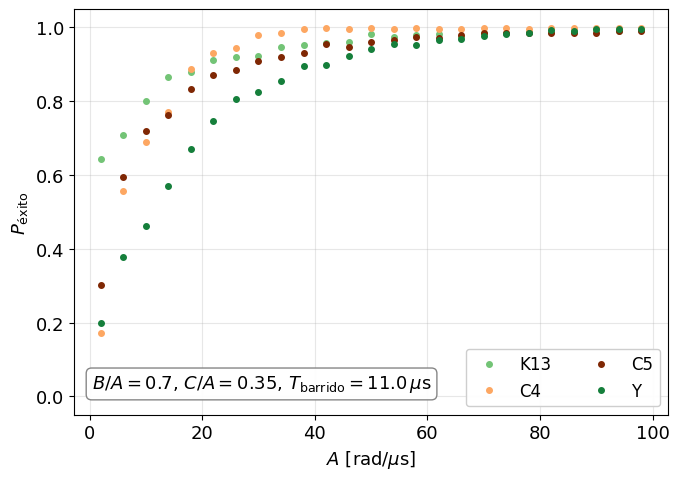

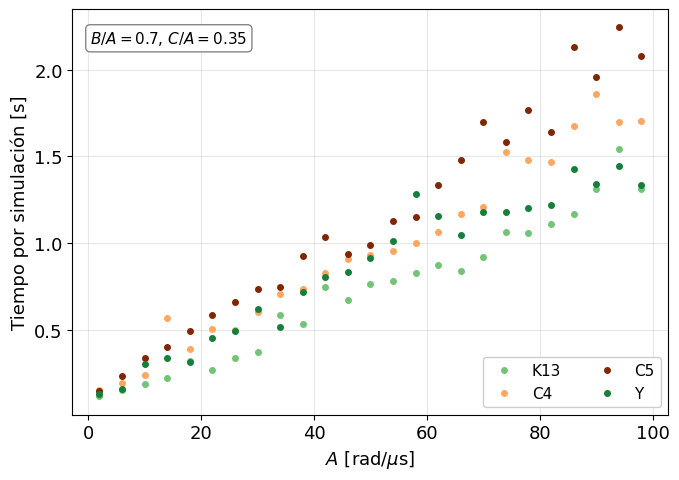

In [ ]:
ratio_B   = 0.7     
ratio_C   = 0.35
A_values  = np.arange(2, 100, 4)
T_barrido = 11.0    

grafos = {
    # "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    # "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    # "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
    # "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),
    
    "K13":   (Q_func_K13, Q_exacta_func_K13, x0_func_K13),
    "C4": (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    "C5": (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    "Y":  (Q_func_Y,  Q_exacta_func_Y,  x0_func_Y_horizontal),
}


resultados_A = {}
tiempos_A    = {}
t0_total = time.time()

for nombre, (Q_func_g, Q_exacta_func_g, x0_func_g) in grafos.items():
    t0_grafo = time.time()
    
    for A in A_values:
        B = ratio_B * A
        C = ratio_C * A
        Q = Q_func_g(A, B, C)

        # Filtro para evitar casos con detuning no positivo
        if np.any(-np.diag(Q) <= 0):
            prob  = np.nan
            t_sim = np.nan
        else:
            try:
                sort_zipped = resolucion_clasica(
                    Q_exacta=Q_exacta_func_g(A, B, C),
                    print_resultados=False,
                )
                geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func_g)

                # Cronómetro: solo la simulación
                t0_sim = time.time()
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, sweep_time=T_barrido, plot=False, n_shots=5000)
                t_sim = time.time() - t0_sim
                
            except Exception:
                prob  = np.nan
                t_sim = np.nan

        resultados_A[(nombre, float(A))] = prob
        tiempos_A[(nombre, float(A))]    = t_sim

    print(f"  [{nombre}] tiempo = {time.time()-t0_grafo:.1f} s")
    
print(f"\nTiempo total de simulación: {time.time()-t0_total:.1f} s")


#### Paleta de colores ####
familias = {
    'P': [n for n in grafos if n.startswith('P')],
    'C': [n for n in grafos if n.startswith('C')],
    'K': [n for n in grafos if n.startswith('K')],
    'Y': [n for n in grafos if n.startswith('Y')],
}

colores = {}
for i, n in enumerate(familias['P']):
    colores[n] = cm.Blues(0.4 + 0.6 * i / max(len(familias['P']) - 1, 1))
for i, n in enumerate(familias['C']):
    colores[n] = cm.Oranges(0.4 + 0.6 * i / max(len(familias['C']) - 1, 1))
for n in familias['K']:
    colores[n] = cm.Greens(0.5)
if 'Y' in grafos:
    colores['Y'] = cm.Greens(0.8)


# Gráfico de probabilidad
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 13})

for nombre in grafos.keys():
    probs = [resultados_A.get((nombre, float(A)), np.nan) for A in A_values]
    plt.plot(A_values, probs, marker='o', markersize=4, linewidth=0,
             label=nombre, color=colores[nombre])

plt.legend(loc='lower right', fontsize=12, framealpha=0.95, ncol=2)
plt.text(0.03, 0.05,
         rf'$B/A={ratio_B}$, $C/A={ratio_C}$, $T_\text{{barrido}}={T_barrido}\,\mu$s',
         transform=plt.gca().transAxes, fontsize=13,
         horizontalalignment='left', verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.95))

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig("barrido_A.png", dpi=200, bbox_inches='tight')
plt.show()


# Gráfico de tiempos
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 13})

for nombre in grafos.keys():
    ts = [tiempos_A.get((nombre, float(A)), np.nan) for A in A_values]
    plt.plot(A_values, ts, marker='o', markersize=4, linewidth=0,
             label=nombre, color=colores[nombre])

plt.legend(loc='lower right', fontsize=11, framealpha=0.95, ncol=2)
plt.text(0.03, 0.95,
         rf'$B/A={ratio_B}$, $C/A={ratio_C}$',
         transform=plt.gca().transAxes, fontsize=11,
         horizontalalignment='left', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.95))

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel('Tiempo por simulación [s]')
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("barrido_A_tiempos.png", dpi=200, bbox_inches='tight')
plt.show()

# Heatmap

La siguiente celda simula para diferentes grafos la dependencia de $P_{éxito}$ de los parámetros $B$ y $C$. Para cambiar los grafos simulados basta con dejar sin comentar su línea en _grafos_. Debido al elevado tiempo de compilación, se ha establecido un paso elevado en el mallado, para ajustarlo basta con editarlo en la línea _paso = 0.12_.

In [7]:
# A = A_solucion =50
# B = B_solucion =0.7*A_solucion
# C = C_solucion =0.35*A_solucion
# x0_func=x0_func_P3
# Q_func = Q_func_P3
# Q_exacta_func = Q_exacta_func_P3



# A_values = [50]

# resultados = {}
# sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion))

# for A in A_values:

#     # paso = 0.03
#     # paso = 0.08
#     paso = 0.12

#     B_values = np.arange(0*A, 1.12*A, paso*A)
#     C_values = np.arange(0*A, 1.12*A, paso*A)

#     t0 = time.time()

#     for B in B_values:
#         for C in C_values:
#             Q = Q_func(A, B, C)
#             diag = -np.diag(Q)
            
#             # Filtro para evitar casoscon detuning negativo
#             if np.any(diag <= -1):
#                 resultados[(A, B, C)] = np.nan
#                 continue
#             try:
#                 geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
#                 prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=2000)
#                 resultados[(A, B, C)] = prob
#             except Exception:
#                 # Si la parametrización genera un ValidationError en Bloqade por física inválida,
#                 # se asigna NaN y el barrido continúa con el siguiente punto.
#                 resultados[(A, B, C)] = np.nan




#     B_unique = sorted(set(k[1] for k in resultados if k[0] == A))
#     C_unique = sorted(set(k[2] for k in resultados if k[0] == A))
#     malla = np.array([[resultados[(A, B, C)] for C in C_unique] for B in B_unique])
#     malla_masked = np.ma.masked_invalid(malla)

#     # Normalizar: B/A y C/B_ref (donde B_ref = 0.5*A como en la definición inicial)
#     B_norm = [b / A for b in B_unique]
#     C_norm = [c / A for c in C_unique] 

#     print(f"A={A}: {time.time() - t0:.2f} s") # Para medir el tiempo de ejecución


#     plt.rcParams.update({'font.size': 17})
#     plt.figure(figsize=(8, 6))
#     plt.imshow(malla_masked, origin='lower', aspect='auto',
#                extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]], #Límites ejes 
#                vmin=0, vmax=1)
#     plt.colorbar(label='Probabilidad de éxito')
#     plt.xlabel('C/A')
#     plt.ylabel('B/A')
#     #plt.title(f'Probabilidad de éxito grafo {nombre_grafo} (A={A} rad/µs)')

#     # Línea B = C
#     x_line = np.linspace(C_norm[0], C_norm[-1], 100)
#     plt.plot(x_line, x_line, color='navy', linestyle='--', linewidth=1.5, label='B = C')

#     # Línea A = B
#     # plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='A = B')

#     #plt.figtext(0.5, -0.02,
#     #        f"Tiempo ejecución = {time.time() - t0:.2f} s  |  Paso = {paso:.2f}",
#     #        ha='center', fontsize=9, style='italic')
#     plt.legend()
#     #plt.savefig(f"mapa_exito_{nombre_grafo} A_{A:.1f}.png")

#     plt.tight_layout()
#     plt.show()

A=50: 19.78 s


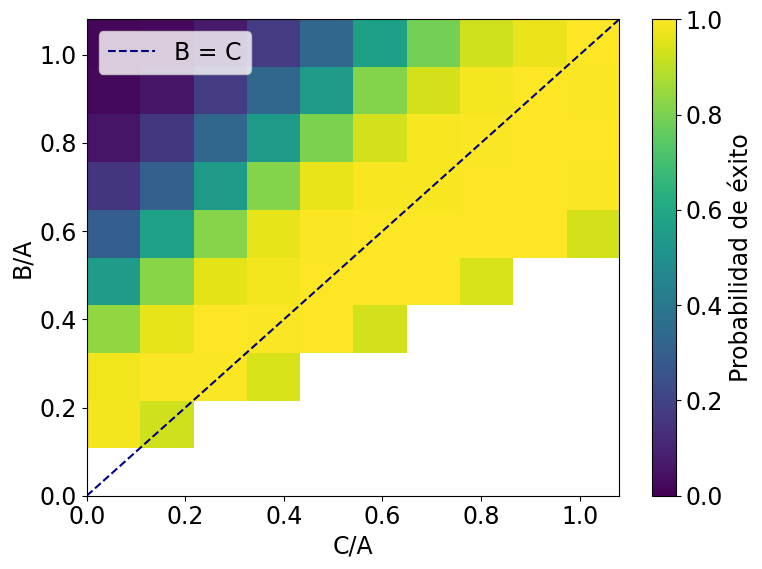

In [8]:
# Listado de grafos sobre los que se generan los heatmaps
grafos = {
    "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    # "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    # "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
    # "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),

    # "K13":  (Q_func_K13, Q_exacta_func_K13, x0_func_K13),
    # "C4":   (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    # "C5":   (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    # "C4mod":(Q_func_C4mod, Q_exacta_func_C4mod, x0_func_C4mod),
    # "Y":    (Q_func_Y,  Q_exacta_func_Y,  x0_func_Y_horizontal),

    # "P7": (Q_func_P7, Q_exacta_func_P7, x0_func_P7),
    # "C6": (Q_func_C6, Q_exacta_func_C6, x0_func_C6),
}


A = A_solucion =50
B = B_solucion =0.7*A_solucion
C = C_solucion =0.35*A_solucion

for nombre_grafo, (Q_func, Q_exacta_func, x0_func) in grafos.items():

    A_values = [50]


    resultados = {}
    sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion))

    for A in A_values:

        paso = 0.12
        # paso = 0.03

        B_values = np.arange(0*A, 1.12*A, paso*A)
        C_values = np.arange(0*A, 1.12*A, paso*A)

        t0 = time.time() # Medirtiempo de ejecución

        for B in B_values:
            for C in C_values:
                Q = Q_func(A, B, C)
                diag = -np.diag(Q)

                # Filtro para evitar casoscon detuning negativo
                if np.any(diag <= 0):
                    resultados[(A, B, C)] = np.nan
                    continue
                try:
                    geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
                    prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=1300)
                    resultados[(A, B, C)] = prob
                except Exception:
                    resultados[(A, B, C)] = np.nan




        B_unique = sorted(set(k[1] for k in resultados if k[0] == A))
        C_unique = sorted(set(k[2] for k in resultados if k[0] == A))
        malla = np.array([[resultados[(A, B, C)] for C in C_unique] for B in B_unique])
        malla_masked = np.ma.masked_invalid(malla)

        # Normalizar: B/A y C/B_ref (donde B_ref = 0.5*A como en la definición inicial)
        B_norm = [b / A for b in B_unique]
        C_norm = [c / A for c in C_unique] 

        print(f"A={A}: {time.time() - t0:.2f} s") # Para medir el tiempo de ejecución

        plt.rcParams.update({'font.size': 17})
        plt.figure(figsize=(8, 6))
        plt.imshow(malla_masked, origin='lower', aspect='auto',
                   extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]], #Esto define los límites de los ejes 
                   vmin=0, vmax=1)
        plt.colorbar(label='Probabilidad de éxito')
        plt.xlabel('C/A')
        plt.ylabel('B/A')
        #plt.title(f'Probabilidad de éxito grafo {nombre_grafo} (A={A} rad/µs)')

        # Línea B = C (en unidades normalizadas B/A = C/A)
        x_line = np.linspace(C_norm[0], C_norm[-1], 100)
        plt.plot(x_line, x_line, color='navy', linestyle='--', linewidth=1.5, label='B = C')

        # Línea A = B
        # plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='A = B')

        #plt.figtext(0.5, -0.02,
        #        f"Tiempo ejecución = {time.time() - t0:.2f} s  |  Paso = {paso:.2f}",
        #        ha='center', fontsize=9, style='italic')
        plt.legend()
        #plt.savefig(f"mapa_exito_{nombre_grafo} A_{A:.1f}.png")

        plt.tight_layout()
        plt.show()

